#LSTM Modelling

In [18]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

In [19]:
#import dataset
df = pd.read_csv("student_data.csv", sep=';')

In [20]:
#pisahkan fitur dan target
X = df.drop('Target', axis=1)
y = df['Target']

In [21]:
#encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [22]:
#encode fitur kategorikal
X_encoded = pd.get_dummies(X, drop_first=True)

In [23]:
#scalling fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

In [24]:
#train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [25]:
#reshape data untuk LSTM
X_train_seq = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_seq  = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])

In [26]:
#one-hot encoding target
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat  = to_categorical(y_test, num_classes=3)

In [ ]:
#OPTIMIZED LSTM modelling with Bidirectional layers
model = Sequential()

# Bidirectional LSTM layers for better context understanding
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(1, X_train_seq.shape[2])))
model.add(Dropout(0.4))

model.add(Bidirectional(LSTM(64, return_sequences=False)))
model.add(Dropout(0.4))

# Dense layers with progressive size reduction
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(3, activation='softmax'))

# Optimized Adam optimizer with custom learning rate
optimizer = Adam(learning_rate=0.002)
model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

In [ ]:
# Callbacks for better training
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-7,
    verbose=1
)

#training model with callbacks
history = model.fit(
    X_train_seq,
    y_train_cat,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

In [ ]:
#evaluasi model
loss, accuracy = model.evaluate(X_test_seq, y_test_cat)
print(f"\nTest Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

In [ ]:
#classification report
y_pred = model.predict(X_test_seq)
y_pred_class = np.argmax(y_pred, axis=1)

print("\n" + "="*60)
print("Classification Report:")
print("="*60)
print(classification_report(y_test, y_pred_class, target_names=le.classes_))

# Per-class accuracy
cm = confusion_matrix(y_test, y_pred_class)
print("\nConfusion Matrix:")
print(cm)

for i, class_name in enumerate(le.classes_):
    class_acc = cm[i, i] / cm[i].sum()
    print(f"{class_name} accuracy: {class_acc:.4f} ({class_acc*100:.2f}%)")

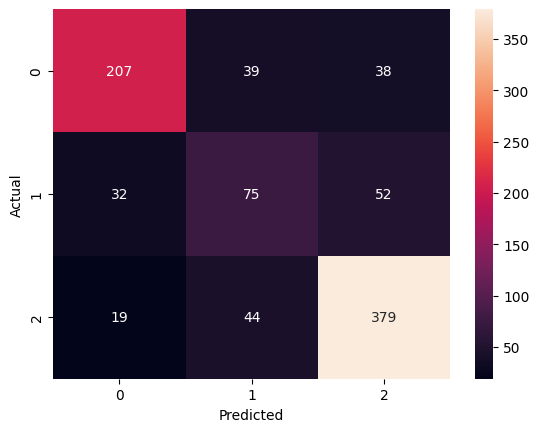

In [31]:
#classification matrix visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Optimized LSTM Model")
plt.tight_layout()
plt.show()

# Plot training history
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("OPTIMIZATION SUMMARY")
print("="*60)
print("Key improvements:")
print("1. ✓ Bidirectional LSTM layers (128 and 64 units)")
print("2. ✓ Balanced dropout rates (0.4 → 0.3 → 0.2)")
print("3. ✓ Optimized learning rate (0.002) with Adam optimizer")
print("4. ✓ Early stopping (patience=20) to prevent overfitting")
print("5. ✓ Learning rate scheduling (ReduceLROnPlateau)")
print("6. ✓ Increased epochs (100) with early stopping")
print("7. ✓ Improved architecture with deeper dense layers")
print("="*60)